# Prophet — MPLS Network Telemetry Forecasting

**Goal**: Train Prophet forecasting models on per-node MPLS telemetry metrics to detect
deviations from predicted behavior (residual-based anomaly detection).

**Lead metrics**: congestion → utilization_pct, bgp_flap → bgp_updates_per_min, mpls_failure → latency_ms

**Strategy**: Grid-search HPO on PE-1 / utilization_pct (normal only), then train 31 models (10 nodes × 3 leads + 1 global).

In [1]:
# Cell 1: Install prophet
!pip install -q prophet
print("Prophet installed.")

Prophet installed.


In [2]:
# Cell 2: Imports
import os, json, gc, warnings, pickle, time, zipfile
from itertools import product

import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
from IPython.display import FileLink

warnings.filterwarnings('ignore')
print(f"pandas {pd.__version__}, prophet OK")

pandas 2.3.3, prophet OK


In [6]:
# Cell 3: Configuration

class Config:
    data_dir = '/kaggle/input/datasets/visheshaggarwal/mpls-network-telemetry'
    model_dir = '/kaggle/working/prophet'
    train_csv = os.path.join(data_dir, 'telemetry_train.csv')
    val_csv = os.path.join(data_dir, 'telemetry_val.csv')

    nodes = ['PE-1', 'PE-2', 'P-1', 'P-2', 'P-3', 'CE-B1', 'CE-B2', 'CE-B3', 'CE-DC1', 'CE-DC2']

    lead_metrics = {
        'congestion': 'utilization_pct',
        'bgp_flap': 'bgp_updates_per_min',
        'mpls_failure': 'latency_ms',
    }

    # BEFORE
    # hpo_params = {
    #     'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.5],
    #     'seasonality_prior_scale': [0.01, 0.1, 1.0, 5.0, 10.0],
    # }
    
    # AFTER
    hpo_params = {
        'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.5],
        'seasonality_prior_scale': [10.0],  # fixed — dominated by changepoint
    }

    freq = '2min'
    weekly_seasonality = False
    daily_seasonality = True
    interval_width = 0.95

cfg = Config()
n_models = len(cfg.nodes) * len(cfg.lead_metrics)
print(f"{len(cfg.nodes)} nodes x {len(cfg.lead_metrics)} lead metrics = {n_models} models")
os.makedirs(cfg.model_dir, exist_ok=True)


10 nodes x 3 lead metrics = 30 models


In [4]:
# Cell 4: Load data

print("Loading training data...")
train_df = pd.read_csv(cfg.train_csv, low_memory=False)
print(f"Train shape: {train_df.shape}")

print("\nLoading validation data...")
val_df = pd.read_csv(cfg.val_csv, low_memory=False)
print(f"Val shape: {val_df.shape}")

train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
val_df['timestamp'] = pd.to_datetime(val_df['timestamp'])
print("Timestamps parsed.")

Loading training data...
Train shape: (1296000, 92)

Loading validation data...
Val shape: (432000, 92)
Timestamps parsed.


In [7]:
# Cell 5: HPO — grid search on PE-1, utilization_pct, normal only

def prepare_ts(df, node, metric, normal_only=True):
    mask = df['node_id'] == node
    if normal_only:
        mask &= ~df['is_anomaly']
    sub = df.loc[mask, ['timestamp', metric]].dropna().copy()
    sub.columns = ['ds', 'y']
    return sub.sort_values('ds').reset_index(drop=True)

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print("Preparing train/val time series for PE-1 / utilization_pct...")
hpo_train = prepare_ts(train_df, 'PE-1', 'utilization_pct')
hpo_val = prepare_ts(val_df, 'PE-1', 'utilization_pct', normal_only=False)
print(f"HPO train: {len(hpo_train)} rows, val: {len(hpo_val)} rows")

grid = ParameterGrid(cfg.hpo_params)
print(f"Grid search over {len(grid)} combinations...")

best_score = np.inf
best_params = None

for i, params in enumerate(grid):
    t0 = time.time()
    m = Prophet(
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        weekly_seasonality=cfg.weekly_seasonality,
        daily_seasonality=cfg.daily_seasonality,
        interval_width=cfg.interval_width,
    )
    m.fit(hpo_train)
    forecast = m.predict(hpo_val[['ds']])
    score = mape(hpo_val['y'].values, forecast['yhat'].values)
    elapsed = time.time() - t0
    print(f"  [{i+1}/{len(grid)}] cps={params['changepoint_prior_scale']:.3f}, sps={params['seasonality_prior_scale']:.2f}  MAPE={score:.2f}%  ({elapsed:.1f}s)")
    if score < best_score:
        best_score = score
        best_params = params
    gc.collect()

print(f"\nBest MAPE: {best_score:.2f}%")
print(f"Best params: {best_params}")

Preparing train/val time series for PE-1 / utilization_pct...
HPO train: 120930 rows, val: 43200 rows
Grid search over 5 combinations...


23:11:04 - cmdstanpy - INFO - Chain [1] start processing
23:11:23 - cmdstanpy - INFO - Chain [1] done processing


  [1/5] cps=0.001, sps=10.00  MAPE=7.25%  (32.6s)


23:11:37 - cmdstanpy - INFO - Chain [1] start processing
23:11:57 - cmdstanpy - INFO - Chain [1] done processing


  [2/5] cps=0.010, sps=10.00  MAPE=7.25%  (31.5s)


...

  [3/5] cps=0.050, sps=10.00  MAPE=7.25%  (23.1s)


23:12:31 - cmdstanpy - INFO - Chain [1] start processing
23:12:56 - cmdstanpy - INFO - Chain [1] done processing


  [4/5] cps=0.100, sps=10.00  MAPE=7.41%  (36.2s)


23:13:07 - cmdstanpy - INFO - Chain [1] start processing
23:13:43 - cmdstanpy - INFO - Chain [1] done processing


  [5/5] cps=0.500, sps=10.00  MAPE=7.38%  (47.0s)

Best MAPE: 7.25%
Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0}


In [8]:
# Cell 6: Train all 31 models with best params

models_info = []
model_idx = 0

for node in cfg.nodes:
    for lead_name, metric in cfg.lead_metrics.items():
        model_idx += 1
        print(f"[{model_idx}/31] Training {node} / {lead_name} ({metric})...", end=' ')
        t0 = time.time()

        train_ts = prepare_ts(train_df, node, metric)
        val_ts = prepare_ts(val_df, node, metric, normal_only=False)

        m = Prophet(
            changepoint_prior_scale=best_params['changepoint_prior_scale'],
            seasonality_prior_scale=best_params['seasonality_prior_scale'],
            weekly_seasonality=cfg.weekly_seasonality,
            daily_seasonality=cfg.daily_seasonality,
            interval_width=cfg.interval_width,
        )
        m.fit(train_ts)

        forecast = m.predict(val_ts[['ds']])
        val_mape = mape(val_ts['y'].values, forecast['yhat'].values)

        fname = f"prophet_{node}_{lead_name}.pkl"
        path = os.path.join(cfg.model_dir, fname)
        with open(path, 'wb') as f:
            pickle.dump(m, f)

        models_info.append({
            'file': fname,
            'node': node,
            'lead': lead_name,
            'metric': metric,
            'val_mape_pct': round(val_mape, 4),
            'train_rows': len(train_ts),
            'val_rows': len(val_ts),
        })
        print(f"MAPE={val_mape:.2f}%, {time.time()-t0:.1f}s")
        gc.collect()

print(f"\nAll {len(models_info)} models trained and saved to {cfg.model_dir}/")

[1/31] Training PE-1 / congestion (utilization_pct)... 

23:17:30 - cmdstanpy - INFO - Chain [1] start processing
23:17:49 - cmdstanpy - INFO - Chain [1] done processing


MAPE=7.25%, 29.4s
[2/31] Training PE-1 / bgp_flap (bgp_updates_per_min)... 

23:18:00 - cmdstanpy - INFO - Chain [1] start processing
23:18:22 - cmdstanpy - INFO - Chain [1] done processing


MAPE=44.53%, 33.8s
[3/31] Training PE-1 / mpls_failure (latency_ms)... 

...

MAPE=6.63%, 41.1s
[29/31] Training CE-DC2 / bgp_flap (bgp_updates_per_min)... 

23:35:07 - cmdstanpy - INFO - Chain [1] start processing
23:35:21 - cmdstanpy - INFO - Chain [1] done processing


MAPE=43.37%, 24.9s
[30/31] Training CE-DC2 / mpls_failure (latency_ms)... 

23:35:32 - cmdstanpy - INFO - Chain [1] start processing
23:36:11 - cmdstanpy - INFO - Chain [1] done processing


MAPE=6.08%, 50.6s

All 30 models trained and saved to /kaggle/working/prophet/


Retraining best model for visualization...


23:36:22 - cmdstanpy - INFO - Chain [1] start processing
23:36:40 - cmdstanpy - INFO - Chain [1] done processing


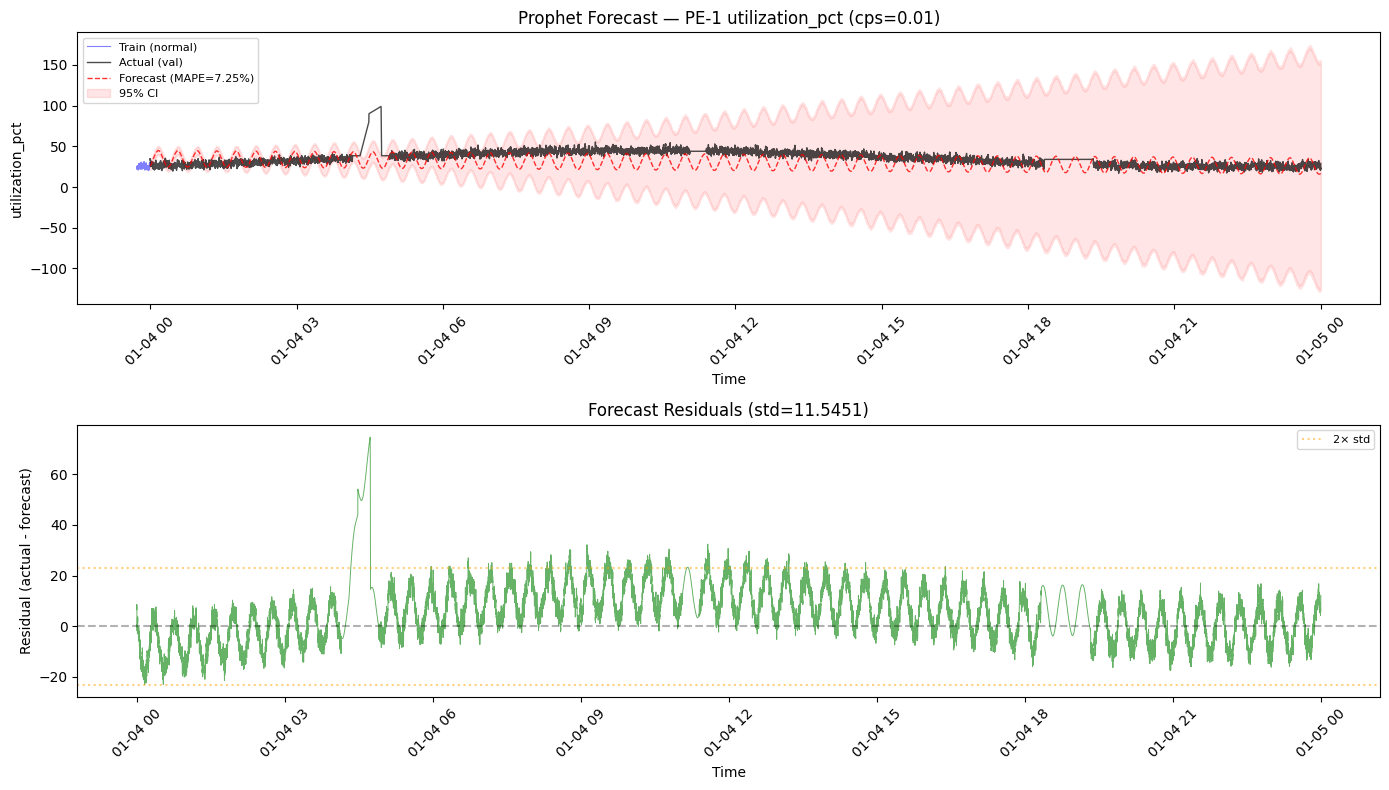

In [9]:
# Viz 1: Best HPO model forecast
import matplotlib.pyplot as plt
import numpy as np

print("Retraining best model for visualization...")
best_m = Prophet(
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    weekly_seasonality=cfg.weekly_seasonality,
    daily_seasonality=cfg.daily_seasonality,
    interval_width=cfg.interval_width,
)
best_m.fit(hpo_train)

future = best_m.make_future_dataframe(periods=len(hpo_val), freq=cfg.freq)
forecast = best_m.predict(future)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(hpo_train['ds'].values[-500:], hpo_train['y'].values[-500:],
        'b-', alpha=0.5, label='Train (normal)', linewidth=0.8)
ax.plot(hpo_val['ds'], hpo_val['y'], 'k-', alpha=0.7, label='Actual (val)', linewidth=1.0)
ax.plot(hpo_val['ds'], forecast['yhat'].values[-len(hpo_val):],
        'r--', alpha=0.8, label=f'Forecast (MAPE={best_score:.2f}%)', linewidth=1.0)
ax.fill_between(hpo_val['ds'],
                forecast['yhat_lower'].values[-len(hpo_val):],
                forecast['yhat_upper'].values[-len(hpo_val):],
                color='r', alpha=0.1, label='95% CI')
ax.set_xlabel('Time')
ax.set_ylabel('utilization_pct')
ax.set_title(f'Prophet Forecast — PE-1 utilization_pct (cps={best_params["changepoint_prior_scale"]})')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
residuals = hpo_val['y'].values - forecast['yhat'].values[-len(hpo_val):]
ax.plot(hpo_val['ds'], residuals, 'g-', alpha=0.6, linewidth=0.7)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axhline(y=np.std(residuals)*2, color='orange', linestyle=':', alpha=0.5, label='2× std')
ax.axhline(y=-np.std(residuals)*2, color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Residual (actual - forecast)')
ax.set_title(f'Forecast Residuals (std={np.std(residuals):.4f})')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

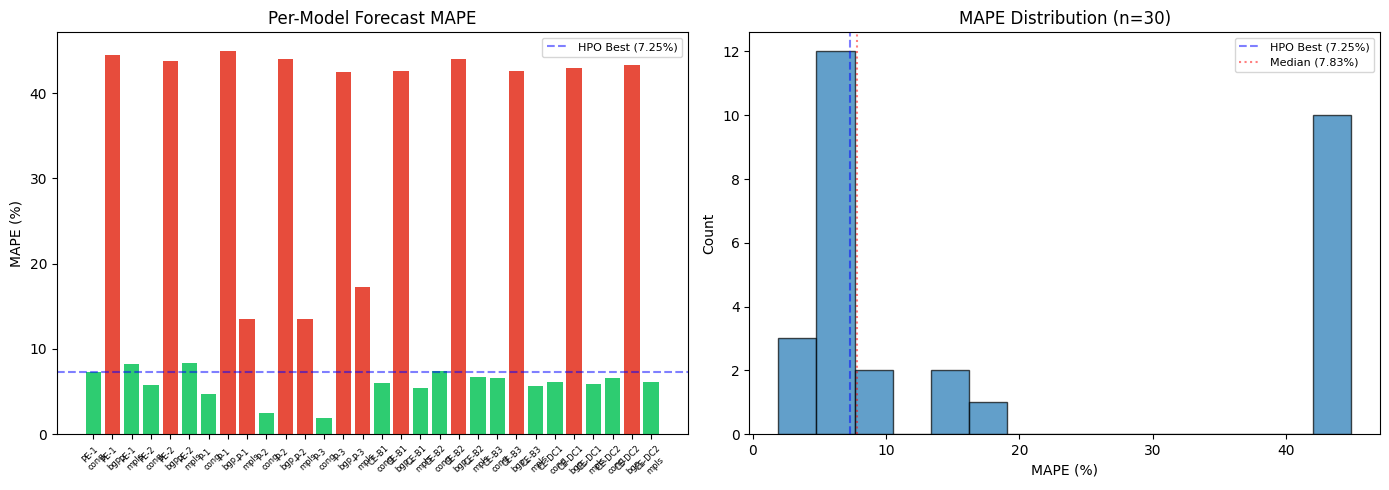

In [14]:
# Viz 2: Training results summary
results_df = pd.DataFrame(models_info)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
labels = [f"{r['node']}\n{r['lead'][:4]}" for r in models_info]
colors = ['#2ecc71' if r['val_mape_pct'] < 10 else '#e74c3c' for r in models_info]
ax.bar(range(len(models_info)), [r['val_mape_pct'] for r in models_info], color=colors)
ax.axhline(y=best_score, color='blue', linestyle='--', alpha=0.5,
           label=f'HPO Best ({best_score:.2f}%)')
ax.set_xticks(range(len(models_info)))
ax.set_xticklabels(labels, fontsize=6, rotation=45)
ax.set_ylabel('MAPE (%)')
ax.set_title('Per-Model Forecast MAPE')
ax.legend(fontsize=8)

ax = axes[1]
all_mape = [r['val_mape_pct'] for r in models_info]
ax.hist(all_mape, bins=15, alpha=0.7, edgecolor='black')
ax.axvline(x=best_score, color='blue', linestyle='--', alpha=0.5,
           label=f'HPO Best ({best_score:.2f}%)')
ax.axvline(x=np.median(all_mape), color='red', linestyle=':', alpha=0.5,
           label=f'Median ({np.median(all_mape):.2f}%)')
ax.set_xlabel('MAPE (%)')
ax.set_ylabel('Count')
ax.set_title(f'MAPE Distribution (n={len(all_mape)})')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
# Cell 7: Create manifest.json

manifest = {
    'project': 'MPLS Network Telemetry — Prophet Forecast Models',
    'description': 'Per-node Prophet forecasting for 3 lead metrics, trained on normal data only.',
    'best_hpo_params': best_params,
    'hpo_search_space': cfg.hpo_params,
    'hpo_node': 'PE-1',
    'hpo_metric': 'utilization_pct',
    'hpo_best_mape_pct': round(best_score, 4),
    'freq': cfg.freq,
    'weekly_seasonality': cfg.weekly_seasonality,
    'daily_seasonality': cfg.daily_seasonality,
    'interval_width': cfg.interval_width,
    'models': models_info,
    'total_models': len(models_info),
}

manifest_path = os.path.join(cfg.model_dir, 'manifest.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"Manifest saved to {manifest_path}")
print(f"Models count: {manifest['total_models']}")

Manifest saved to /kaggle/working/prophet/manifest.json
Models count: 30


In [12]:
# Cell 8: Zip and download

zip_path = '/kaggle/working/prophet_models.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(cfg.model_dir):
        fpath = os.path.join(cfg.model_dir, fname)
        zf.write(fpath, fname)

size_mb = os.path.getsize(zip_path) / 1024 / 1024
print(f"Zip created: {zip_path} ({size_mb:.1f} MB)")
display(FileLink(zip_path))

Zip created: /kaggle/working/prophet_models.zip (111.5 MB)


/kaggle/working/prophet_models.zip

In [13]:
# Cell 9: Summary

print("=" * 60)
print("PROPHET — TRAINING SUMMARY")
print("=" * 60)
print(f"\nBest HPO params (PE-1 / utilization_pct):")
print(f"  changepoint_prior_scale: {best_params['changepoint_prior_scale']}")
print(f"  seasonality_prior_scale:  {best_params['seasonality_prior_scale']}")
print(f"  Val MAPE: {best_score:.2f}%")
print(f"\nTrained {len(models_info)} models:")
for m in models_info:
    print(f"  {m['node']:<8s} / {m['lead']:<15s}  MAPE={m['val_mape_pct']:.2f}%  train={m['train_rows']}  val={m['val_rows']}")
print(f"\nModels saved to: {cfg.model_dir}/")
print(f"Manifest: {manifest_path}")
print(f"Archive: {zip_path}")
print("=" * 60)

PROPHET — TRAINING SUMMARY

Best HPO params (PE-1 / utilization_pct):
  changepoint_prior_scale: 0.01
  seasonality_prior_scale:  10.0
  Val MAPE: 7.25%

Trained 30 models:
  PE-1     / congestion       MAPE=7.25%  train=120930  val=43200
  PE-1     / bgp_flap         MAPE=44.53%  train=120930  val=43200
  PE-1     / mpls_failure     MAPE=8.23%  train=120930  val=43200
  PE-2     / congestion       MAPE=5.77%  train=119580  val=43200
  PE-2     / bgp_flap         MAPE=43.79%  train=119580  val=43200
  PE-2     / mpls_failure     MAPE=8.33%  train=119580  val=43200
  P-1      / congestion       MAPE=4.66%  train=122280  val=43200
  P-1      / bgp_flap         MAPE=44.90%  train=122280  val=43200
  P-1      / mpls_failure     MAPE=13.49%  train=122280  val=43200
  P-2      / congestion       MAPE=2.53%  train=126600  val=43200
  P-2      / bgp_flap         MAPE=44.03%  train=126600  val=43200
  P-2      / mpls_failure     MAPE=13.54%  train=126600  val=43200
  P-3      / congestion      